In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import dijet
import random
import pandas as pd
from scipy.interpolate import interp1d
import importlib
importlib.reload(dijet)

# setup plotting
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["axes.labelsize"] = 25  
plt.rcParams["xtick.labelsize"] = 20  
plt.rcParams["ytick.labelsize"] = 20
plt.rcParams["axes.titlesize"] = 18  
plt.rcParams["text.usetex"] = True
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"
%config InlineBackend.figure_format = 'retina'
plt.rcParams['axes.xmargin'] = 0

In [30]:
kins = dijet.Kinematics(x=0.005, Q=2, s=50**2, delta=0.0, z=0.5)
kins.y = (kins.Q**2)/(kins.x * kins.s)
assert kins.y < 1, f'y={kins.y}>1'

pTs = np.linspace(0.5, 10, 100)
space = {
    'y': [0.05, 0.95],
    'z': [0.2, 0.5],
    'Q2': [16, 100],
    't': 0.1,
    'phi_Dp': [0, 2*np.pi],
    'phi_kp': [0, 2*np.pi]
}
r0 = 0.5

dj = dijet.DIJET(lambdaIR=0.4, fit_type='pp', IR_reg=['gauss', 1.5], only_tt=True)
sigma_tt = dj.get_integrated_xsec(pTs, kins.s, space, points=4, r0=r0, kind='den')

dj = dijet.DIJET(lambdaIR=0.4, fit_type='pp', IR_reg=['gauss', 1.5], only_ll=True)
sigma_ll = dj.get_integrated_xsec(pTs, kins.s, space, points=4, r0=r0, kind='den')

dj = dijet.DIJET(lambdaIR=0.4, fit_type='pp', IR_reg=['gauss', 1.5])
sigma_all = dj.get_integrated_xsec(pTs, kins.s, space, points=4, r0=r0, kind='den')



--> !! only using transverse term in unpolarized cross section!!
--> loaded replica 1
--> !! only using longitudinal term in unpolarized cross section!!
--> loaded replica 1
--> loaded replica 1


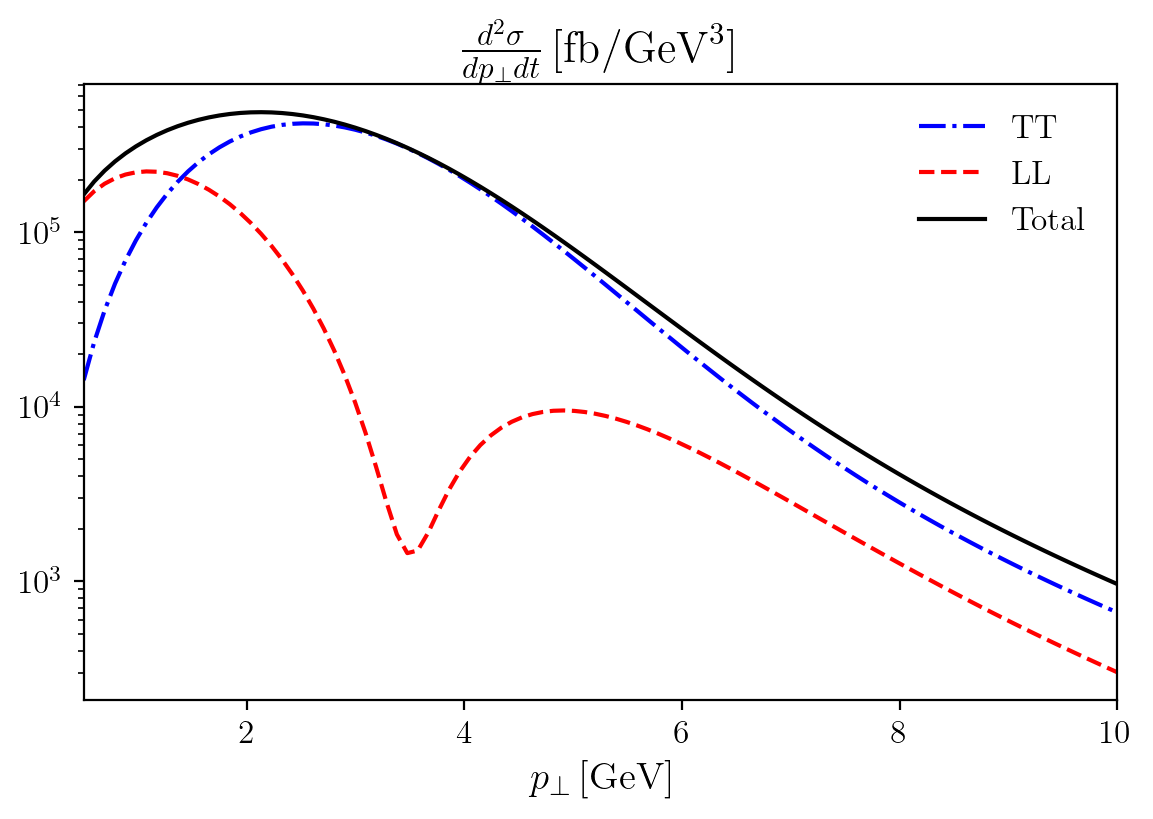

In [29]:
asp_ratio = 5/3
psize = 4
nrows, ncols = 1,1
fig, ax = plt.subplots(nrows, ncols, figsize=(asp_ratio*psize*ncols, psize*nrows))

ax.plot(pTs, sigma_tt, color='blue', linestyle='-.', label='TT')
ax.plot(pTs, sigma_ll, color='red', linestyle='--', label='LL')
ax.plot(pTs, sigma_all, color='black', linestyle='-', label='Total')

ax.legend(frameon=False)
ax.set_xlabel(r'$p_\perp \, [\mathrm{GeV}]$')
ax.set_title(r'$\frac{d^2 \sigma}{dp_\perp dt}\, [\mathrm{fb}/\mathrm{GeV}^3]$')
ax.semilogy()

plt.show()

